# Monthly prefix analysis

Runs `analyze` on every `prefixes-*.parquet` file in the project root and plots:

1. A bar chart of items with a processing baseline below 5 per month.
2. A stacked bar chart of prefix counts per baseline per month.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt

from mspc_sentinel_2_check import Analysis, analyze

In [2]:
root = Path.cwd().parent
pattern = re.compile(r"^prefixes-(\d{4})-(\d{2})\.parquet$")
results: dict[str, Analysis] = {}
for path in sorted(root.glob("prefixes-*.parquet")):
    match = pattern.match(path.name)
    if match is None:
        continue
    year, month = match.groups()
    results[f"{year}-{month}"] = analyze(str(path))
list(results)

['2022-11', '2022-12', '2023-01', '2023-02', '2023-03']

## Items below baseline 5 per month

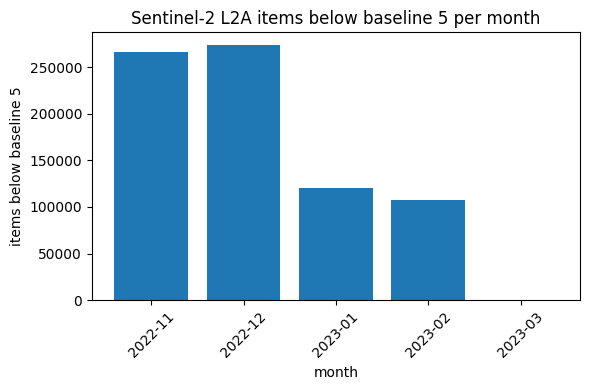

In [3]:
labels = list(results.keys())
values = [r.below_baseline_5 for r in results.values()]
fig, ax = plt.subplots(figsize=(max(6, len(labels) * 0.5), 4))
ax.bar(labels, values)
ax.set_xlabel("month")
ax.set_ylabel("items below baseline 5")
ax.set_title("Sentinel-2 L2A items below baseline 5 per month")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

## Prefix count per baseline per month

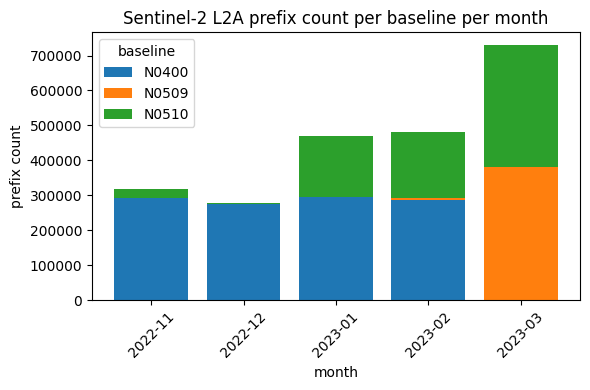

In [4]:
baselines = sorted({b for r in results.values() for b in r.by_baseline})
fig, ax = plt.subplots(figsize=(max(6, len(labels) * 0.5), 4))
bottom = [0] * len(labels)
for baseline in baselines:
    counts = [results[m].by_baseline.get(baseline, 0) for m in labels]
    ax.bar(labels, counts, bottom=bottom, label=baseline)
    bottom = [b + c for b, c in zip(bottom, counts)]
ax.set_xlabel("month")
ax.set_ylabel("prefix count")
ax.set_title("Sentinel-2 L2A prefix count per baseline per month")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="baseline")
fig.tight_layout()
plt.show()